In [3]:
import os
from glob import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms.v2 as transforms
import torchvision.tv_tensors as tv_tensors
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from matplotlib.colors import ListedColormap, BoundaryNorm

Loading images and masks from dataset, then filtering only the ones that have assigned mask.

In [24]:
root_dir = "../data/old_dataset"
out_dir="../logs/test_model"


# Get all log directories, each directory represents a wooden log
log_folders = [f for f in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, f))]

image_paths = sorted(glob(os.path.join(root_dir, "**", "*.jpg"), recursive=True))
mask_paths = sorted(glob(os.path.join(root_dir, "**", "PixelLabelData", "*.png"), recursive=True))

# Create a dictionary to match images with masks
mask_filenames = {
    os.path.basename(mask).replace("Label_1_", "").replace(".png", ".jpg"): mask for mask in mask_paths
}

# Keep only valid image-mask pairs
filtered_image_paths = []
filtered_mask_paths = []

for img_path in image_paths:
    img_filename = os.path.basename(img_path)
    
    if img_filename in mask_filenames:
        filtered_image_paths.append(img_path)
        filtered_mask_paths.append(mask_filenames[img_filename])
        
print(f"Filtered Total Images: {len(filtered_image_paths)}")
print(f"Filtered Total Masks: {len(filtered_mask_paths)}")

Filtered Total Images: 286
Filtered Total Masks: 286


From EDA we know that for each log the ct scans have different resolution. We also know that towards the edgeline its just background. Therefore, we crop the images to the same resolution.

Crops both image and mask to the bounding box of non-background in the mask. This ensures we do not cut of pixels from the actual tree and utilize cropping as much as possible before having to resize to desired resolution.

In [5]:
def crop_to_foreground(img, mask, margin=10):
    coords = np.column_stack(np.where(mask > 0))  # Non-background pixels
    if coords.size == 0:
        return img, mask 

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    # Add margin and clip to image bounds
    y_min = max(y_min - margin, 0)
    x_min = max(x_min - margin, 0)
    y_max = min(y_max + margin, img.shape[0])
    x_max = min(x_max + margin, img.shape[1])

    cropped_img = img[y_min:y_max, x_min:x_max]
    cropped_mask = mask[y_min:y_max, x_min:x_max]

    return cropped_img, cropped_mask


Loading the img mask pair, cropping and resizing, normilizing and lastly necessary conversion to pytorch tensor.

In [6]:
def preprocess_pair(img_path, mask_path, target_size=(256, 256)):
    # Load grayscale image and mask
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    # Crop around wooden log area
    img, mask = crop_to_foreground(img, mask)
    
    assert isinstance(target_size, tuple), f"Expected target_size to be a tuple, got {type(target_size)}"
    
    # Resize both to target shape
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)

    # Normalize image
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)  # Shape: [1, H, W]

    # Convert class 9 to 3 (Dutina)
    mask[mask == 9] = 3

    # Convert to torch tensors
    img_tensor = torch.tensor(img, dtype=torch.float32)
    mask_tensor = torch.tensor(mask, dtype=torch.long)  # Must be long for CE loss

    return img_tensor, mask_tensor


Testing and visualizing the correctness of the crop.

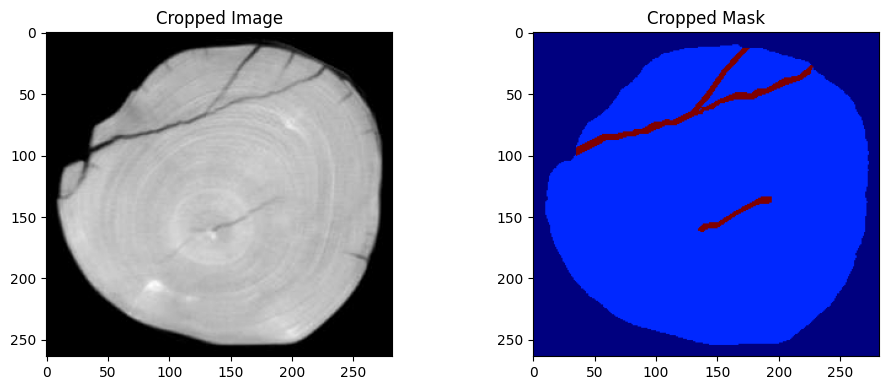

In [7]:
def load_image_and_mask(img_path, mask_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)         # Loads CT scan as grayscale
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)       # Loads mask (label values from 0-6)
    return img, mask
    
img, mask = load_image_and_mask(filtered_image_paths[1], filtered_mask_paths[1])
cropped_img, cropped_mask = crop_to_foreground(img, mask)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cropped_img, cmap="gray")
plt.title("Cropped Image")

plt.subplot(1, 2, 2)
plt.imshow(cropped_mask, cmap="jet")
plt.title("Cropped Mask")

plt.tight_layout()
plt.show()

Utilizing pytorch dataset as a preprocessing pipeline. Firstly reads the dataset as it has been established, then whenever getting the item from the dataset, apply preprocessing pipeline.

In [8]:
class WoodDefectDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, mask_paths, size=(256, 256)):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.size = size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img, mask = preprocess_pair(self.image_paths[idx], self.mask_paths[idx], self.size)
        return img, mask

In [9]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0.0):
        self.patience = patience
        self.delta = delta

        self.best_score = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
            return

        if current_score < self.best_score - self.delta:
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [10]:
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    filtered_image_paths,
    filtered_mask_paths,
    test_size=0.2,
    random_state=42
)

In [11]:
train_dataset = WoodDefectDataset(train_imgs, train_masks)
val_dataset   = WoodDefectDataset(val_imgs, val_masks)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)

## We use IoU as a metric. We calculate both mean overall IoU and per class Iou. Pixel accuracy is not good metric, since majority of pixels are either background or healthy parts of a tree.

In [12]:
def compute_iou(preds, targets, num_classes=7, ignore_index=None, return_per_class=False):
    # Computes mean IoU and optionally per-class IoUs.
    preds = preds.view(-1)
    targets = targets.view(-1)
    ious = []

    for cls in range(num_classes):
        if ignore_index is not None and cls == ignore_index:
            ious.append(float('nan'))
            continue

        pred_mask = preds == cls
        target_mask = targets == cls

        intersection = (pred_mask & target_mask).sum().float()
        union = (pred_mask | target_mask).sum().float()

        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append((intersection / union).item())

    mean_iou = np.nanmean(ious)

    if return_per_class:
        return mean_iou, ious
    else:
        return mean_iou

def get_per_class_ious(mrf = False):
    _, _, per_class_ious = evaluate(model, val_loader, use_mrf=mrf)

    class_names = ["Background", "Obvod", "Hniloba", "Dutina", "HrcaZ", "HrcaN", "Trhlina"]
    print("\nFinal Per-Class IoU:")
    for i, iou in enumerate(per_class_ious):
        print(f"{class_names[i]:<10} | IoU: {iou:.4f}")

## Comparative visualization to evaluate models performance beyond just through numbers.

In [13]:
def visualize_mask_comparison(model):
    CLASS_COLORS = np.array([
        [0, 0, 128],     # Class 0: Dark Blue
        [0, 128, 0],     # Class 1: Green
        [128, 0, 0],     # Class 2: Dark Red
        [128, 128, 0],   # Class 3: Olive
        [0, 128, 128],   # Class 4: Teal
        [128, 0, 128],   # Class 5: Purple
        [255, 165, 0]    # Class 6: Orange
    ]) / 255.0
    
    cmap = ListedColormap(CLASS_COLORS[:7])  # Use only 7 colors
    bounds = np.arange(8)  # Class boundaries (0 to 7)
    norm = BoundaryNorm(bounds, cmap.N)
    
    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    
    
    with torch.no_grad():
        for idx, (images, masks) in enumerate(val_loader):
            images, masks = images.to(device), masks.to(device)
    
            outputs = model(images)
            loss = criterion(outputs, masks)
    
            val_loss += loss.item()
    
            preds = torch.argmax(outputs, dim=1)
            batch_iou = compute_iou(preds, masks, num_classes=7)
    
            print(val_loss, val_iou)
            for pred_idx, pred in enumerate(preds):
                print(pred.shape, masks[pred_idx].shape)
                plt.figure(figsize=(10, 4))
                plt.subplot(1, 2, 1)
                plt.imshow(pred.cpu().numpy(), cmap=cmap, norm=norm)
                plt.colorbar()
                plt.title("Predicted Mask")
                
                plt.subplot(1, 2, 2)
                plt.imshow(masks[pred_idx].cpu().numpy(), cmap=cmap, norm=norm)
                plt.colorbar()
                plt.title("Real Mask")
                
                plt.tight_layout()
                plt.show()
            val_iou += batch_iou
            if idx == 2:
                break
    
    print(val_loss, val_iou)

## Utilizing graph probabilistic model for post-processing.
Markov Random Fields with Gibbs Sampling calculates energy cost for each pixel and its potential labels. The lowest energy is picked. Calculation is based on the probability of the class for pixel from CNN and its neighbours. This should ensure that any "holes" in the defects should be filled in as well as smoothening out the edges.

In [14]:
def mrf_gibbs_sampling(prob_map, iterations=5, beta=0.8):
    C, H, W = prob_map.shape
    device = prob_map.device

    # Initial guess for labels: Each pixel is assigned the class with the highest probability
    labels = torch.argmax(prob_map, dim=0)  # [H, W]

    # Define convolutional kernel to count neighbors (8-neighborhood)
    kernel = torch.ones((1, 1, 3, 3), device=device)  # 3x3
    kernel[0, 0, 1, 1] = 0  # exclude center pixel

    for _ in range(iterations):
        for cls in range(C):
            # Create binary map for current class
            class_map = (labels == cls).float().unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]

            # Count how many neighbors have this class
            neighbor_count = F.conv2d(class_map, kernel, padding=1).squeeze()  # [H, W]
            
            # Beta - neighbour count
            if cls == 0:
                smooth_costs = 8 - neighbor_count.unsqueeze(0)
            else:
                smooth_costs = torch.cat([smooth_costs, (8 - neighbor_count).unsqueeze(0)], dim=0)

        # Unary term: -log(prob)
        unary = -torch.log(prob_map + 1e-6)

        # Energy = unary + beta * pairwise disagreement
        energy = unary + beta * smooth_costs

        # Pick label with lowest energy
        labels = torch.argmin(energy, dim=0)

    return labels

In [15]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs=10, do_early_stopping=False, use_mrf=False, print_results=True):
    best_val_iou = 0.0
    best_epoch = 0
    best_per_class_ious = []
    best_model_state = None

    if do_early_stopping:
        early_stopping = EarlyStopping(patience=15, delta=0.001)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_iou = 0.0

        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            batch_iou = compute_iou(preds, masks, num_classes=7)
            running_iou += batch_iou

        avg_train_loss = running_loss / len(train_loader)
        avg_train_iou = running_iou / len(train_loader)

        val_loss, val_iou, per_class_ious = evaluate(model, criterion, optimizer, val_loader, use_mrf)

        # Save best model info
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            best_per_class_ious = per_class_ious
            best_epoch = epoch + 1
            best_model_state = model.state_dict()
            torch.save(model.state_dict(), os.path.join(out_dir, "checkpoints", "best.pt"))

        if do_early_stopping:
            early_stopping(val_loss)
            if early_stopping.early_stop:
                if print_results:
                    print(f"Early stopping triggered at epoch {epoch+1}")
                break
        if print_results:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.4f} | Train mIoU: {avg_train_iou:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val mIoU: {val_iou:.4f}")

    # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)

    # Report best results
    if print_results:
        class_names = ["Background", "Obvod", "Hniloba", "Dutina", "HrcaZ", "HrcaN", "Trhlina"]
        print(f"\nBest Validation IoU: {best_val_iou:.4f} (epoch {best_epoch})")
        print("Best Per-Class IoU:")
        for i, iou in enumerate(best_per_class_ious):
            print(f"{class_names[i]:<10} | IoU: {iou:.4f}")
    
        visualize_mask_comparison(model=model)

    return model, best_val_iou, best_per_class_ious

In [16]:
def evaluate(model, criterion, optimizer, val_loader, use_mrf=False):
    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    ious_per_class = [[] for _ in range(7)]

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            if use_mrf:
                probs = torch.softmax(outputs, dim=1)

                batch_ious = []
                for i in range(probs.shape[0]):
                    smoothed = mrf_gibbs_sampling(probs[i])
                    target = masks[i]
                    
                    iou, class_ious = compute_iou(smoothed, target, num_classes=7, return_per_class=True)
                    batch_ious.append(iou)

                    for cls, cls_iou in enumerate(class_ious):
                        if not np.isnan(cls_iou):
                            ious_per_class[cls].append(cls_iou)

                val_iou += sum(batch_ious) / len(batch_ious)
            else:
                preds = torch.argmax(outputs, dim=1)
                batch_ious = []
                for i in range(preds.shape[0]):
                    iou, class_ious = compute_iou(preds[i], masks[i], num_classes=7, return_per_class=True)
                    batch_ious.append(iou)

                    for cls, cls_iou in enumerate(class_ious):
                        if not np.isnan(cls_iou):
                            ious_per_class[cls].append(cls_iou)

                val_iou += sum(batch_ious) / len(batch_ious)

    avg_per_class_ious = [np.nanmean(c) if c else float('nan') for c in ious_per_class]
    return val_loss / len(val_loader), val_iou / len(val_loader), avg_per_class_ious

In [17]:
class DilatedSegCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=7):
        super(DilatedSegCNN, self).__init__()
        
        self.pool = nn.MaxPool2d(2)
        
        # Encoder with increasing dilation
        self.enc1 = self._conv_block(in_channels, 64, dilation=1)
        self.enc2 = self._conv_block(64, 128, dilation=2)
        self.enc3 = self._conv_block(128, 256, dilation=4)
        self.enc4 = self._conv_block(256, 512, dilation=8)

        # Decoder
        self.dec3 = self._upconv_block(512, 256)
        self.dec2 = self._upconv_block(256, 128)
        self.dec1 = self._upconv_block(128, 64)
        
        # Final classifier
        self.classifier = nn.Conv2d(64, num_classes, kernel_size=1)

    def _conv_block(self, in_c, out_c, dilation):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=dilation, dilation=dilation),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=dilation, dilation=dilation),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def _upconv_block(self, in_c, out_c):
        return nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x0 = x
        
        # Encoder
        x1 = self.enc1(x0)         
        x2 = self.enc2(self.pool(x1))  
        x3 = self.enc3(self.pool(x2))      
        # Bottleneck
        x4 = self.enc4(self.pool(x3))

        # Decoder
        x = self.dec3(x4) + x3    # Skip connection
        x = self.dec2(x) + x2
        x = self.dec1(x) + x1

        out = self.classifier(x)
        return out

## Testing augmented larger dataset
Next we want to test whether larger dataset improves models performance. We do this by implementind augmentations during pre-processing of data. Now, it will have 5 repeats: first repeat is the same as it worked previously, next 4 repeats has in addition applied random augmentation and createing a new data point. This means that the dataset will be 5 times larger before.
The only realistic cases of transform seem to be rotation and flip. Any transpose, crop, blur and so on seem like they will never happen in reality during making of the CT scans.

In [20]:
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=(-180, 180)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
])

val_transform = None#transforms.Compose([])

class WoodAugmentedDataset(Dataset):
    def __init__(self, image_paths, mask_paths, size=(256, 256), transform=None, repeat=5):
        self.original_image_paths = image_paths
        self.original_mask_paths = mask_paths
        self.size = size
        self.transform = transform
        self.repeat = repeat

        self.image_paths = image_paths * repeat
        self.mask_paths = mask_paths * repeat

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        base_idx = idx % len(self.original_image_paths)
        repeat_idx = idx // len(self.original_image_paths)

        img_path = self.original_image_paths[base_idx]
        mask_path = self.original_mask_paths[base_idx]

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

        img, mask = crop_to_foreground(img, mask)
        img = cv2.resize(img, self.size, interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, self.size, interpolation=cv2.INTER_NEAREST)

        img = img.astype("float32") / 255.0
        img = np.expand_dims(img, axis=0)

        # Convert unexpected class 9 to 3(Dutina)
        mask[mask == 9] = 3

        img_tensor = tv_tensors.Image(torch.tensor(img, dtype=torch.float32))
        mask_tensor = tv_tensors.Mask(torch.tensor(mask, dtype=torch.long))

        # Only apply transform if this is not the first repeat
        if self.transform and repeat_idx > 0:
            img_tensor, mask_tensor = self.transform(img_tensor, mask_tensor)

        return img_tensor, mask_tensor

Image shape: (256, 256), Mask shape: (256, 256)
Unique mask values: [0 1 2 6]


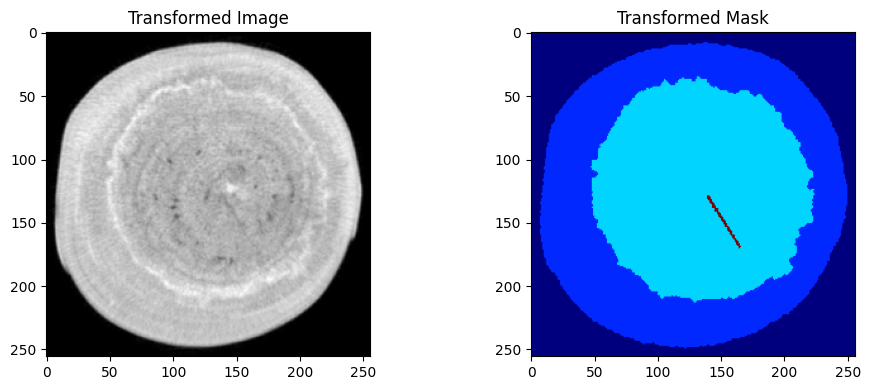

Image shape: (256, 256), Mask shape: (256, 256)
Unique mask values: [0 1 4]


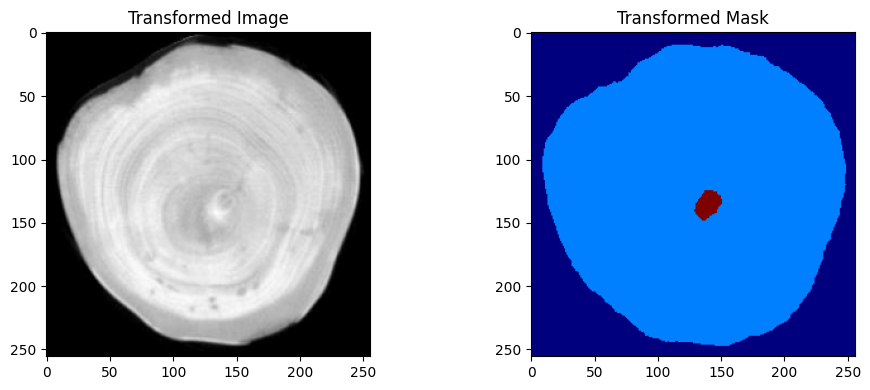

Image shape: (256, 256), Mask shape: (256, 256)
Unique mask values: [0 1 2]


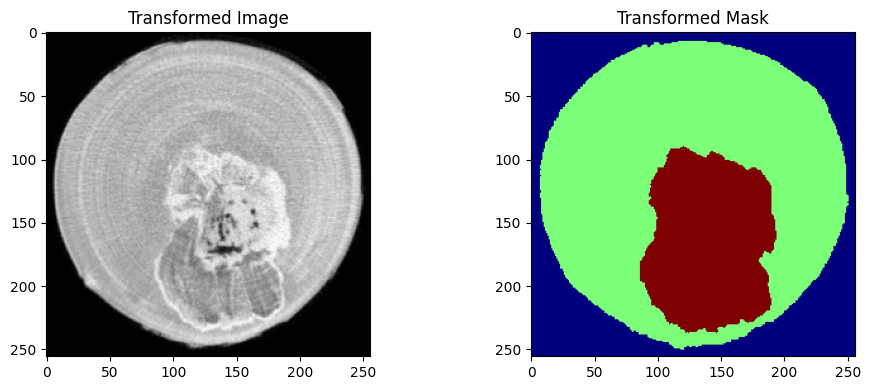

Image shape: (256, 256), Mask shape: (256, 256)
Unique mask values: [0 1 4]


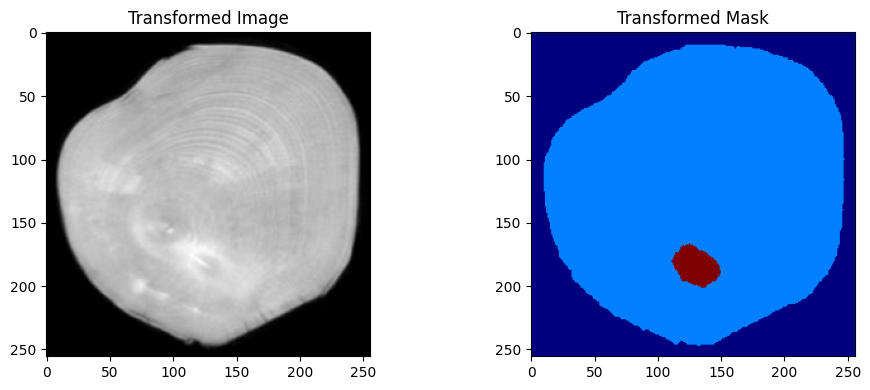

Image shape: (256, 256), Mask shape: (256, 256)
Unique mask values: [0 1 4]


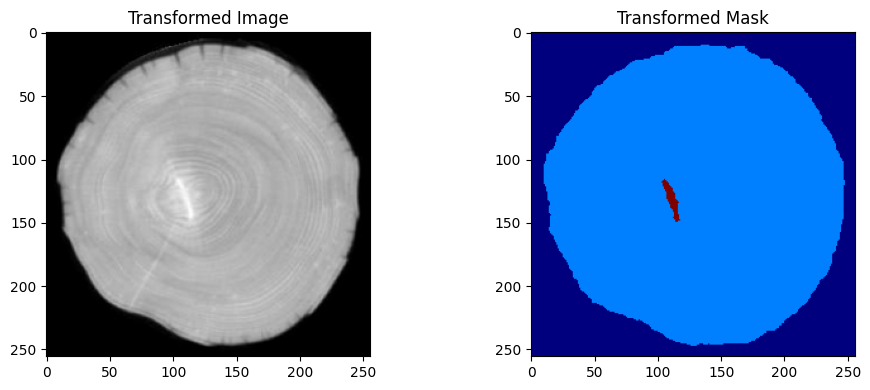

Image shape: (256, 256), Mask shape: (256, 256)
Unique mask values: [0 1 2 4]


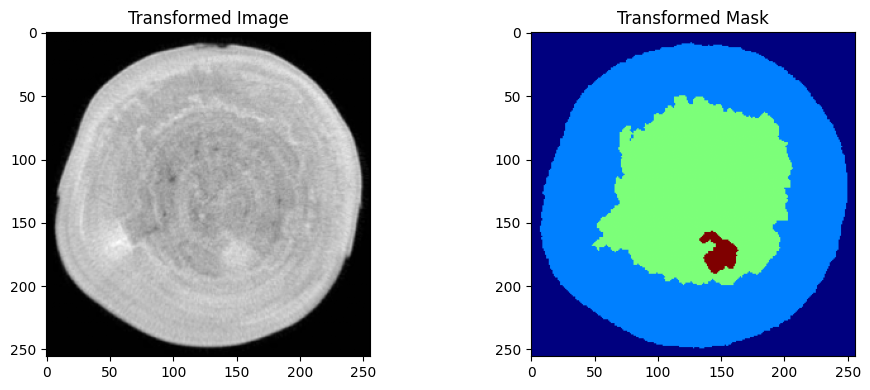

In [21]:
def visualize_sample(dataset, num_samples=3):
    """Function to visualize transformed images and masks"""
    for i in range(num_samples):
        img, mask = dataset[i]

        img = img.squeeze(0).cpu().numpy()  # Convert to NumPy
        mask = mask.cpu().numpy()

        print(f"Image shape: {img.shape}, Mask shape: {mask.shape}")
        print(f"Unique mask values: {np.unique(mask)}")

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(img, cmap="gray")
        plt.title("Transformed Image")

        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap="jet")
        plt.title("Transformed Mask")

        plt.tight_layout()
        plt.show()

train_augmented_dataset = WoodAugmentedDataset(train_imgs, train_masks, transform=train_transform)
visualize_sample(train_dataset, num_samples=3)

val_augmented_dataset = WoodAugmentedDataset(val_imgs, val_masks, transform=val_transform)
visualize_sample(val_dataset, num_samples=3)

In [22]:
train_augmented_loader = DataLoader(train_augmented_dataset, batch_size=8, shuffle=True)
val_augmented_loader = DataLoader(val_augmented_dataset, batch_size=8, shuffle=False)

Epoch 1/200 | Train Loss: 0.2371 | Train mIoU: 0.3616 | Val Loss: 0.4983 | Val mIoU: 0.4860
Epoch 2/200 | Train Loss: 0.1542 | Train mIoU: 0.4059 | Val Loss: 0.1503 | Val mIoU: 0.6377
Epoch 3/200 | Train Loss: 0.1338 | Train mIoU: 0.4319 | Val Loss: 0.1188 | Val mIoU: 0.6435
Epoch 4/200 | Train Loss: 0.1231 | Train mIoU: 0.4645 | Val Loss: 0.1389 | Val mIoU: 0.6326
Epoch 5/200 | Train Loss: 0.1148 | Train mIoU: 0.4950 | Val Loss: 0.0947 | Val mIoU: 0.7020
Epoch 6/200 | Train Loss: 0.1147 | Train mIoU: 0.4913 | Val Loss: 0.0860 | Val mIoU: 0.7008
Epoch 7/200 | Train Loss: 0.1031 | Train mIoU: 0.5320 | Val Loss: 0.0932 | Val mIoU: 0.7002
Epoch 8/200 | Train Loss: 0.0910 | Train mIoU: 0.5505 | Val Loss: 0.0832 | Val mIoU: 0.7453
Epoch 9/200 | Train Loss: 0.0832 | Train mIoU: 0.5695 | Val Loss: 0.1402 | Val mIoU: 0.6709
Epoch 10/200 | Train Loss: 0.0800 | Train mIoU: 0.5688 | Val Loss: 0.0786 | Val mIoU: 0.6954
Epoch 11/200 | Train Loss: 0.0726 | Train mIoU: 0.5987 | Val Loss: 0.0663 | Val

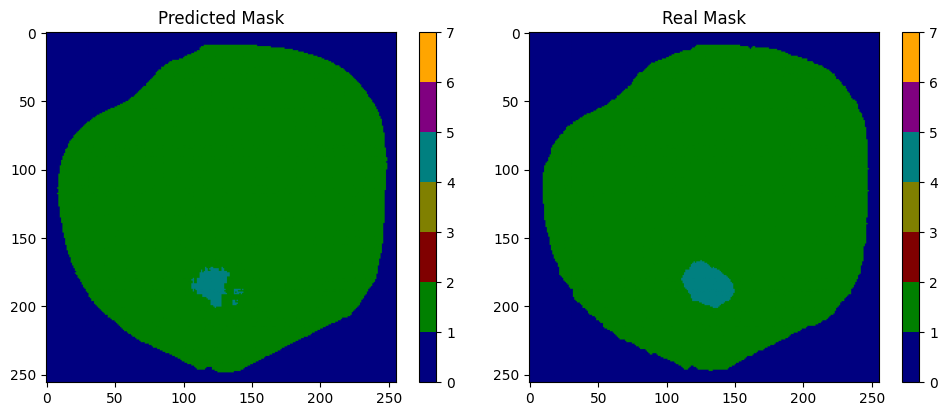

torch.Size([256, 256]) torch.Size([256, 256])


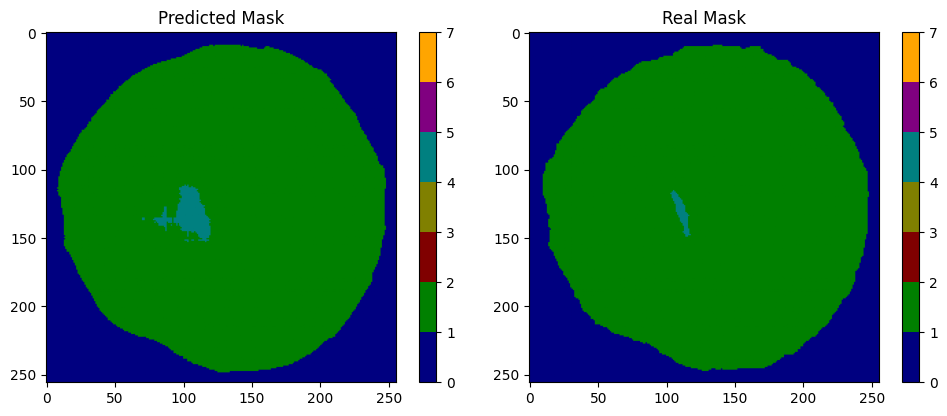

torch.Size([256, 256]) torch.Size([256, 256])


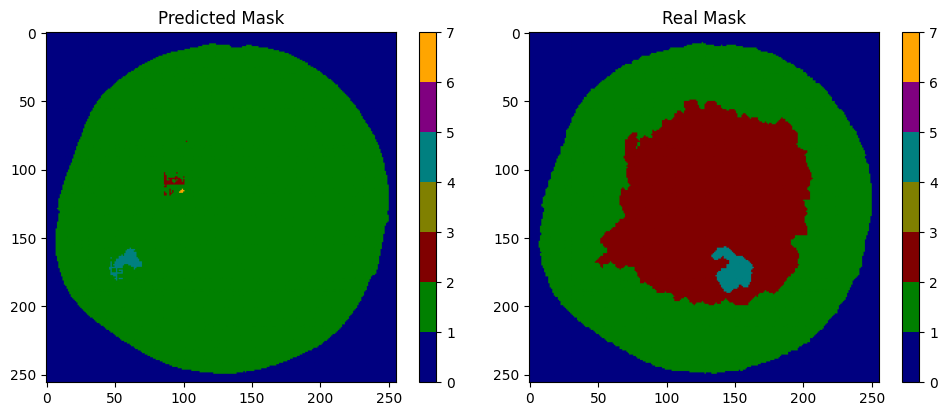

torch.Size([256, 256]) torch.Size([256, 256])


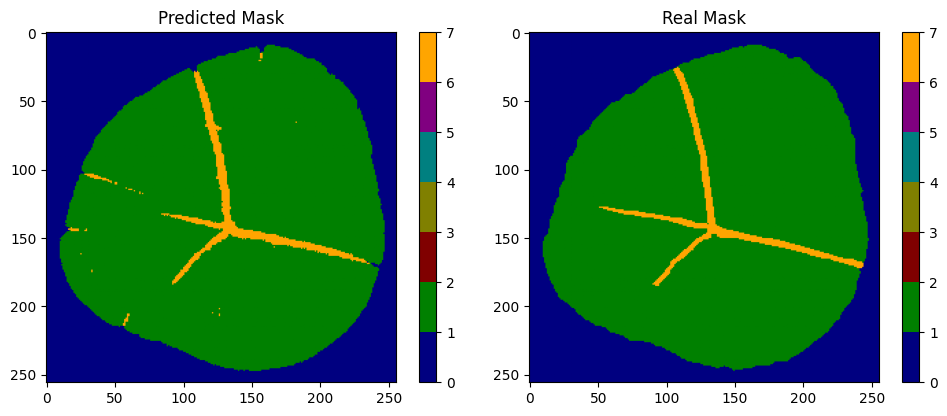

torch.Size([256, 256]) torch.Size([256, 256])


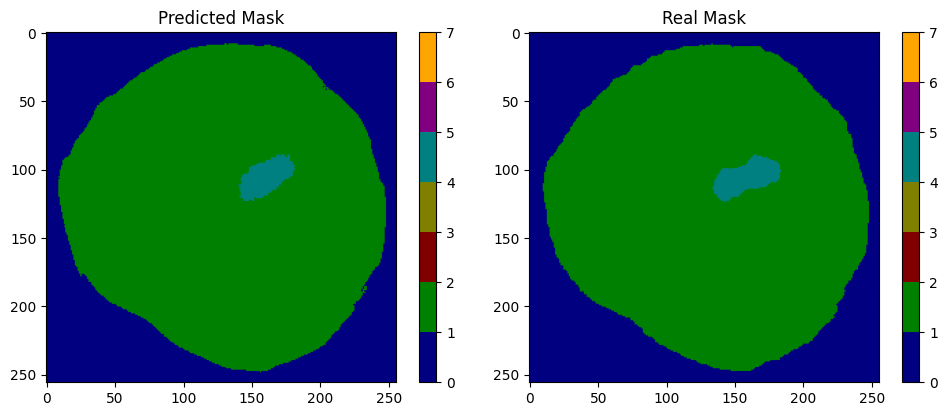

torch.Size([256, 256]) torch.Size([256, 256])


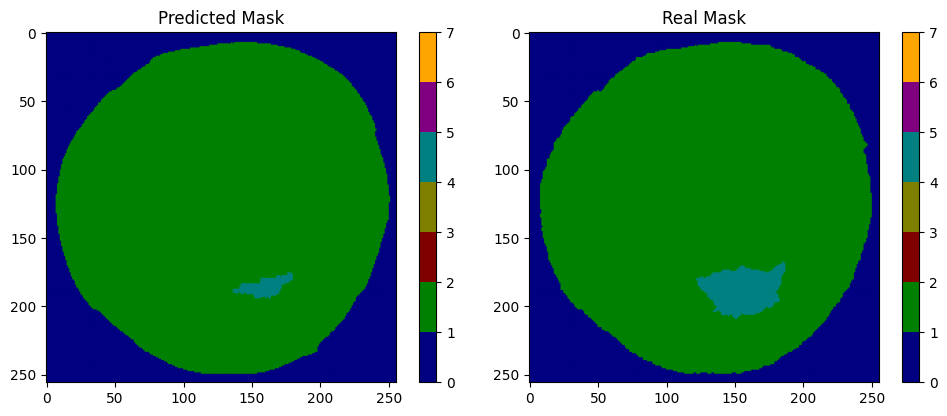

torch.Size([256, 256]) torch.Size([256, 256])


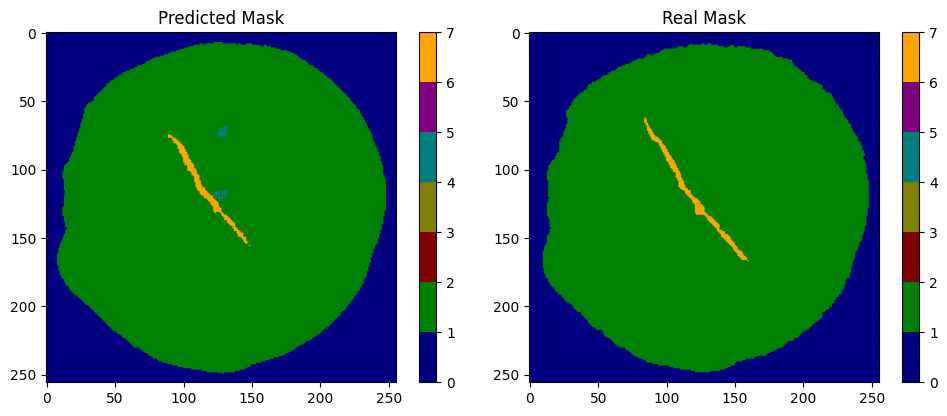

torch.Size([256, 256]) torch.Size([256, 256])


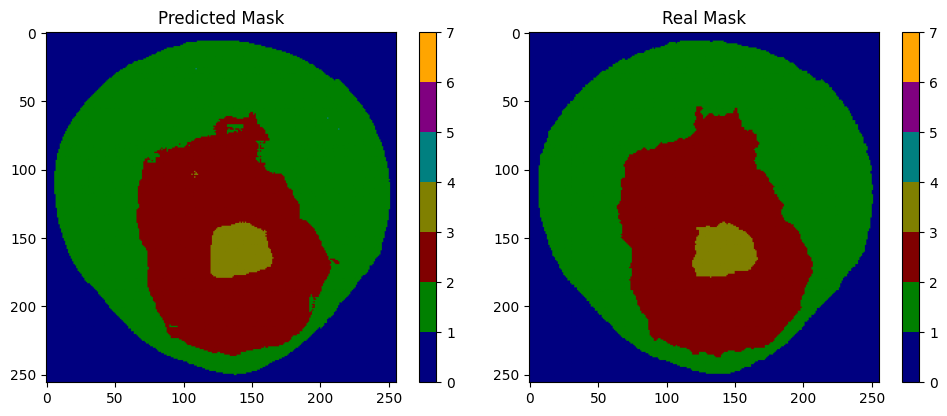

0.3270663842558861 0.712579275170962
torch.Size([256, 256]) torch.Size([256, 256])


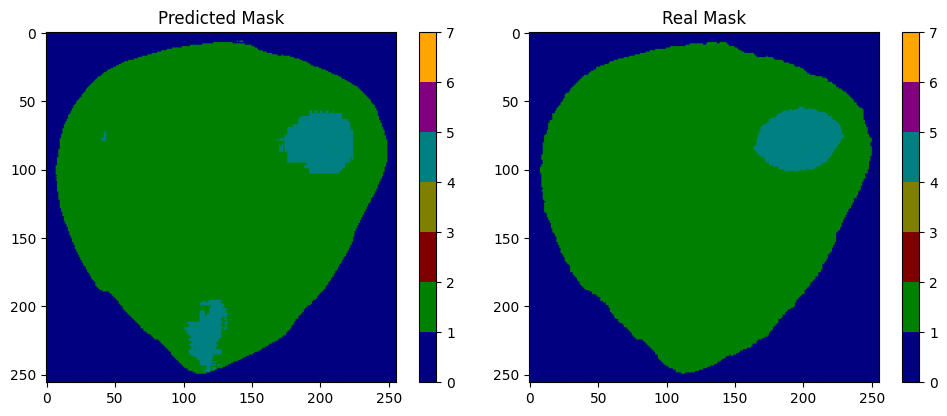

torch.Size([256, 256]) torch.Size([256, 256])


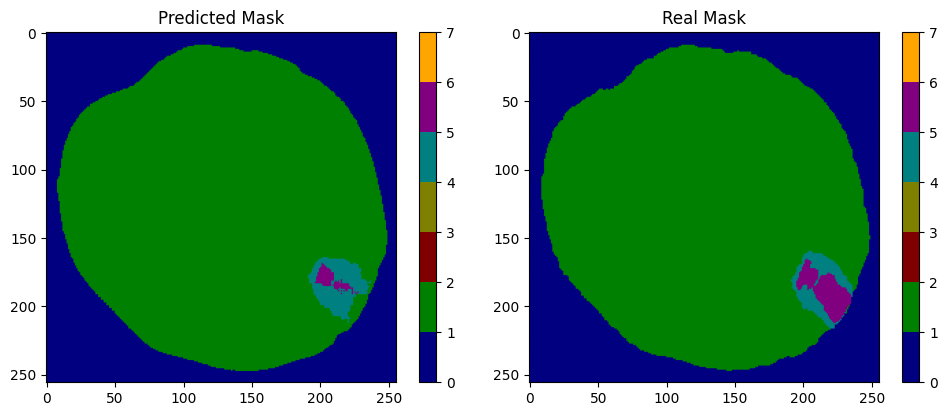

torch.Size([256, 256]) torch.Size([256, 256])


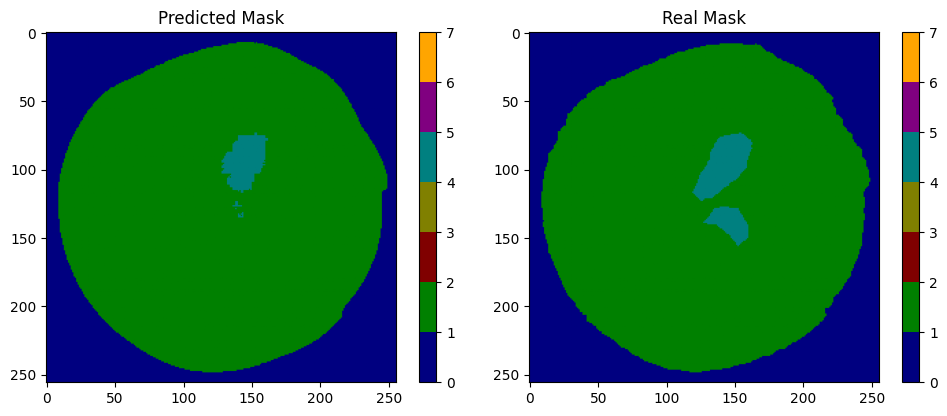

torch.Size([256, 256]) torch.Size([256, 256])


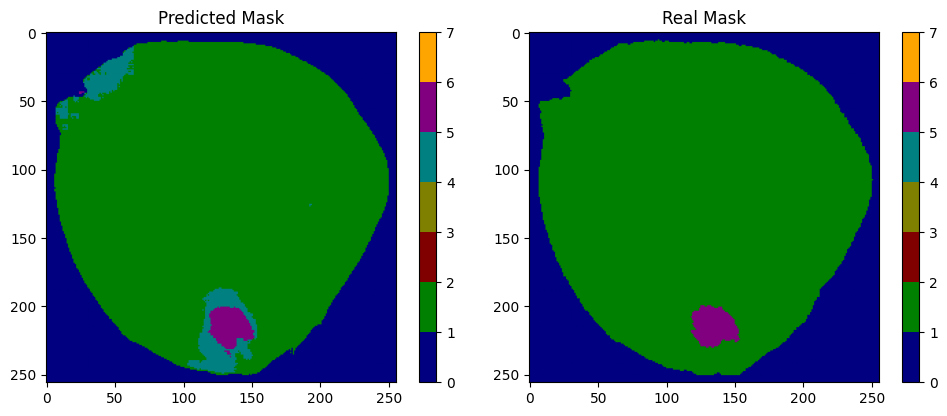

torch.Size([256, 256]) torch.Size([256, 256])


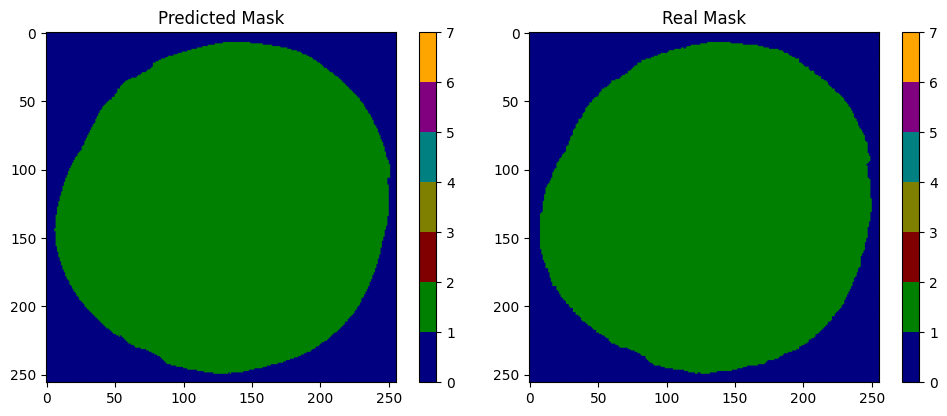

torch.Size([256, 256]) torch.Size([256, 256])


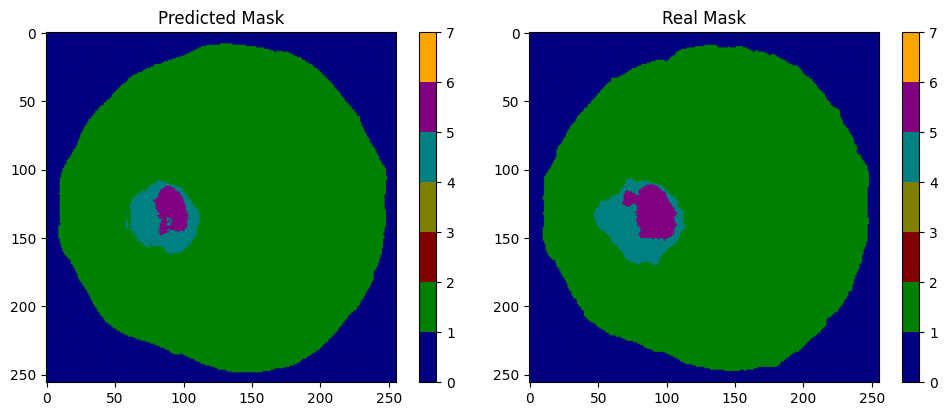

torch.Size([256, 256]) torch.Size([256, 256])


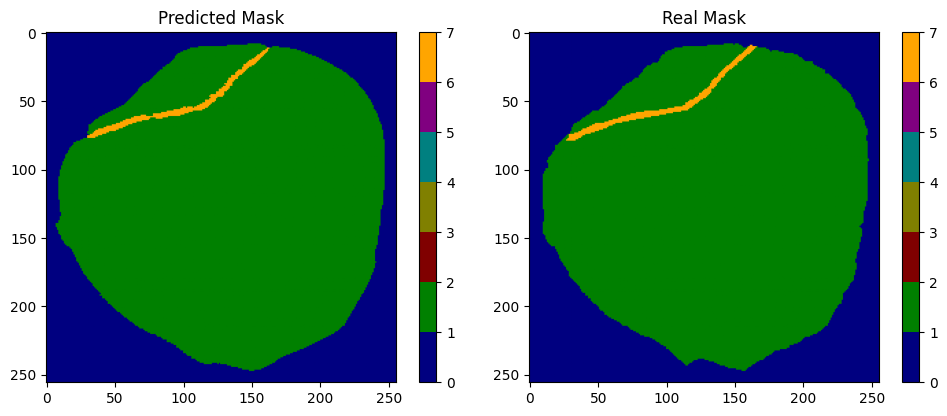

torch.Size([256, 256]) torch.Size([256, 256])


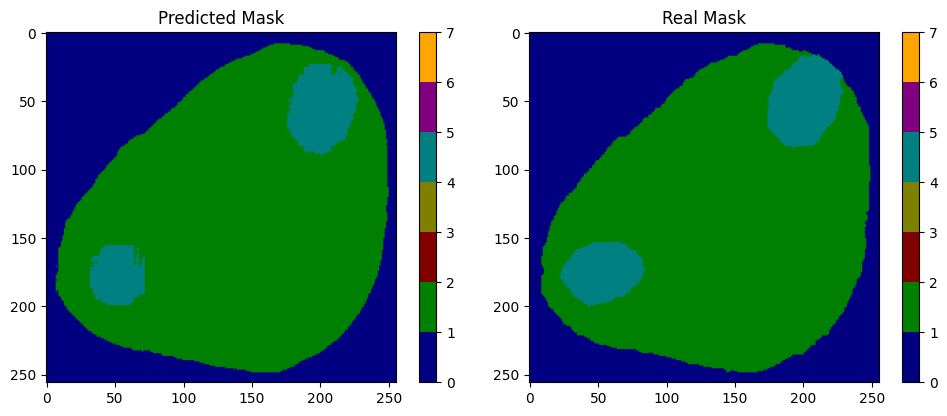

0.41324781626462936 1.459315515557925
torch.Size([256, 256]) torch.Size([256, 256])


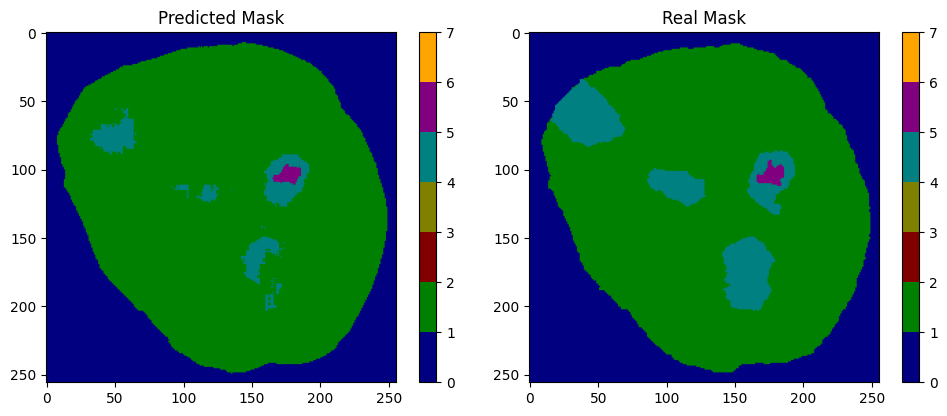

torch.Size([256, 256]) torch.Size([256, 256])


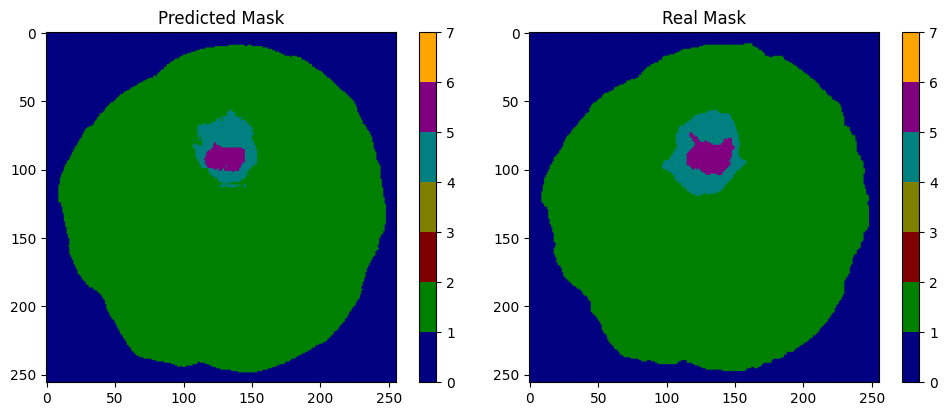

torch.Size([256, 256]) torch.Size([256, 256])


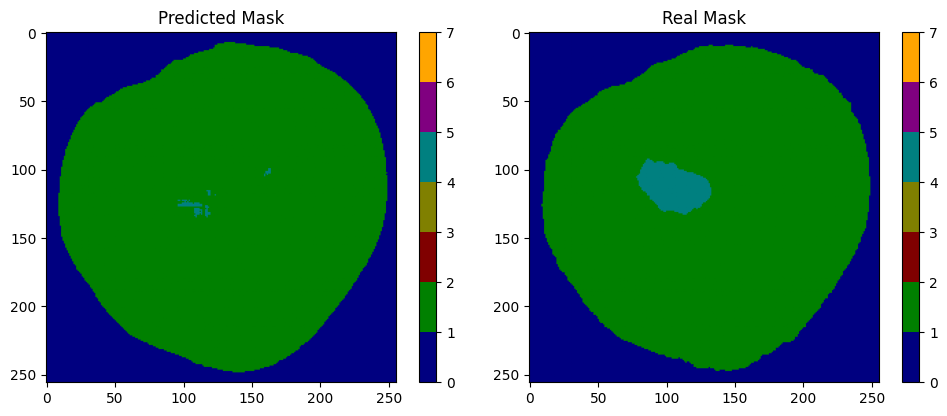

torch.Size([256, 256]) torch.Size([256, 256])


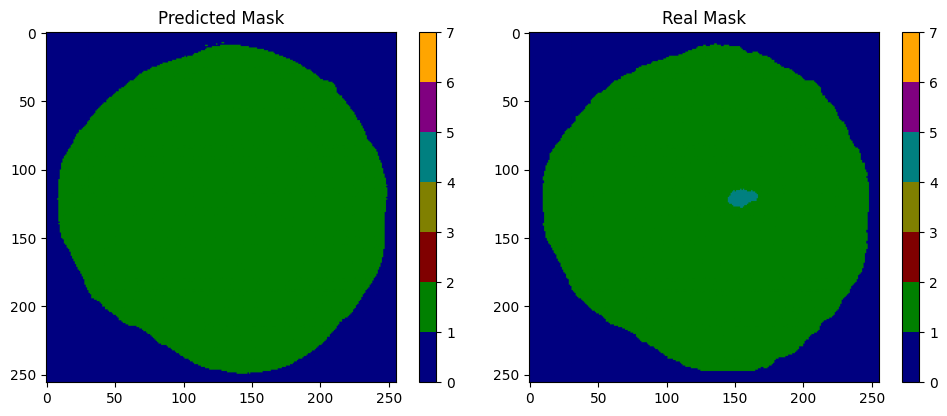

torch.Size([256, 256]) torch.Size([256, 256])


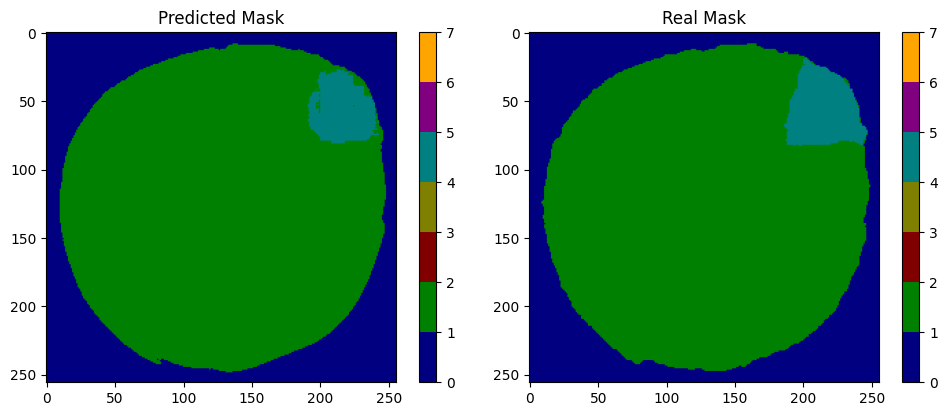

torch.Size([256, 256]) torch.Size([256, 256])


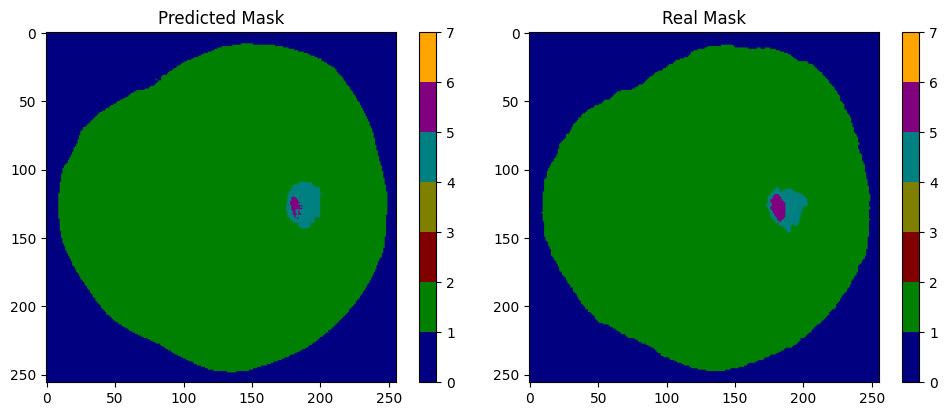

torch.Size([256, 256]) torch.Size([256, 256])


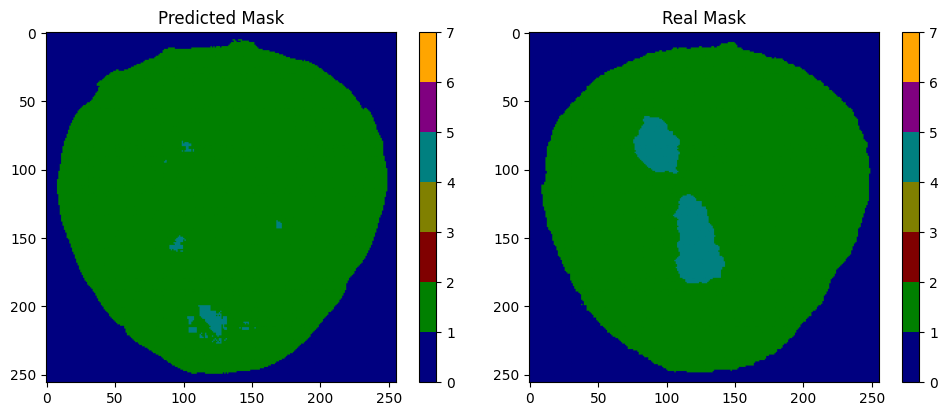

torch.Size([256, 256]) torch.Size([256, 256])


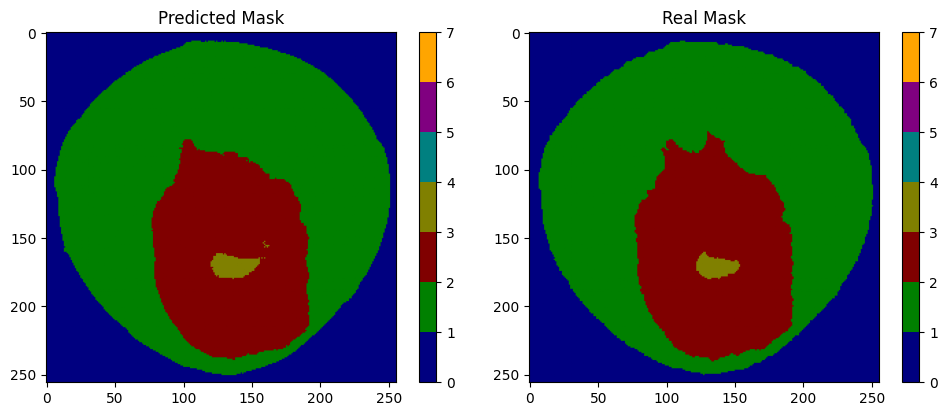

0.41324781626462936 2.2425907075405123


(DilatedSegCNN(
   (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
   (enc1): Sequential(
     (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU(inplace=True)
     (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (5): ReLU(inplace=True)
   )
   (enc2): Sequential(
     (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2))
     (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU(inplace=True)
     (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2))
     (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (5): ReLU(inplace=True)
   )
   (enc3): Sequential(
 

In [26]:
model = DilatedSegCNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_model(model, criterion, optimizer, train_augmented_loader, val_augmented_loader, epochs=200, do_early_stopping=True, use_mrf=True)